# 13 — GDELT news-timing analyse

**Onderzoeksvraag**: Postte Trump *vóór* of *na* het nieuws? En maakt dat verschil
voor de marktreactie?

**Methodologische motivatie**: De bulk-event-studies (nb 11, 12) konden het
*common cause* probleem niet oplossen: zowel Trump's posts als marktbewegingen
kunnen reageren op hetzelfde onderliggende nieuws. Via GDELT kunnen we voor elke
post bepalen wanneer het eerste nieuwsbericht over het topic verscheen, en zo
posts labelen als:
- **Reactief**: Trump postte ná het nieuws (common cause, geen causaal effect verwacht)
- **Potentieel informatief**: geen matching nieuwsbericht gevonden in 4u vóór de post
  (Trump als mogelijke informatieve bron)

**Data**: `data/processed/gdelt_news_timing.parquet`

In [1]:
%load_ext autoreload
%autoreload 2

import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', context='notebook')

DATA    = Path('../data')
FIGURES = Path('../reports/figures')
FIGURES.mkdir(parents=True, exist_ok=True)
print('Setup klaar.')

Setup klaar.


## 1. Laad GDELT timing data

In [ ]:
try:
    gdelt = pd.read_parquet(DATA / 'processed/gdelt_news_timing.parquet', engine='pyarrow')
except Exception:
    gdelt = pd.read_parquet(DATA / 'processed/gdelt_news_timing.parquet', engine='fastparquet')

gdelt['post_time'] = pd.to_datetime(gdelt['post_time'], utc=True)
gdelt['first_news_time'] = pd.to_datetime(gdelt['first_news_time'], utc=True)

# Label: reactief = nieuws gevonden vóór post | informatief = geen nieuws gevonden
gdelt['label'] = gdelt['trump_after_news'].astype('boolean').map({
    True:  'reactief',
    False: 'informatief',
})
gdelt.loc[gdelt['first_news_time'].isna(), 'label'] = 'geen_nieuws'

print(f'Totaal: {len(gdelt)} posts')
print()
print(gdelt.groupby(['topic', 'label']).size().to_string())
print()
print('Lag (minuten) — reactieve posts:')
print(gdelt[gdelt['label']=='reactief'].groupby('topic')['lag_minutes'].describe().round(1))

## 2. Lag distributie: hoe lang na het nieuws post Trump?

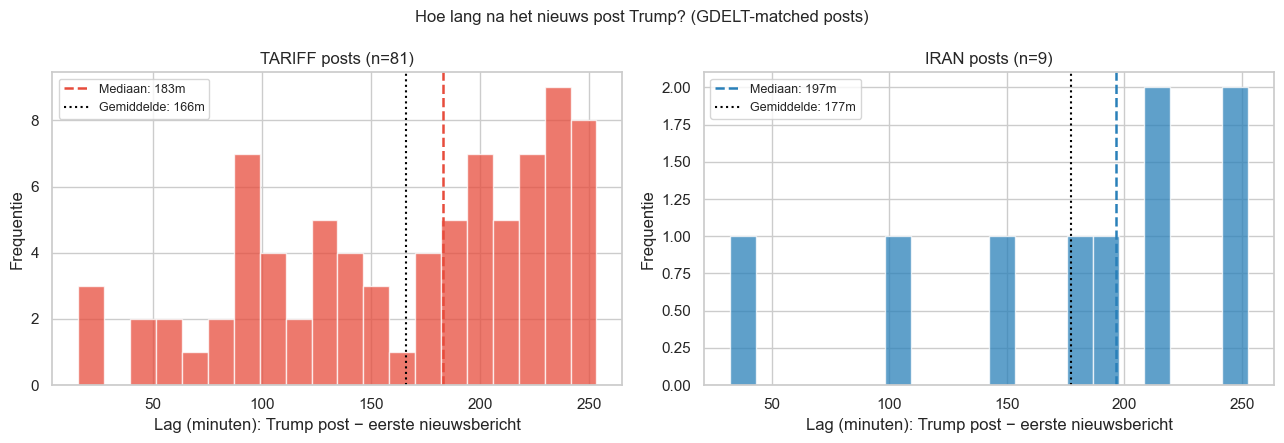

Opgeslagen: reports/figures/13_lag_distributie.png


In [3]:
reactive = gdelt[gdelt['label'] == 'reactief']

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, topic, color in [
    (axes[0], 'tariff', '#e74c3c'),
    (axes[1], 'iran',   '#2980b9'),
]:
    sub = reactive[reactive['topic'] == topic]['lag_minutes']
    if sub.empty:
        ax.set_title(f'{topic.upper()} — geen data')
        continue
    ax.hist(sub, bins=20, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(sub.median(), color=color, linestyle='--', linewidth=1.8,
               label=f'Mediaan: {sub.median():.0f}m')
    ax.axvline(sub.mean(),   color='black', linestyle=':', linewidth=1.5,
               label=f'Gemiddelde: {sub.mean():.0f}m')
    ax.set_xlabel('Lag (minuten): Trump post − eerste nieuwsbericht')
    ax.set_ylabel('Frequentie')
    ax.set_title(f'{topic.upper()} posts (n={len(sub)})')
    ax.legend(fontsize=9)

plt.suptitle('Hoe lang na het nieuws post Trump? (GDELT-matched posts)', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES / '13_lag_distributie.png', dpi=150, bbox_inches='tight')
plt.show()
print('Opgeslagen: reports/figures/13_lag_distributie.png')

## 3. Koppel aan marktdata: CAR per label

Herbereken de dagelijkse returns per label:
- **reactief**: Trump postte na het nieuws → markt had al gereageerd
- **geen_nieuws**: geen matching nieuwsbericht gevonden → potentieel informatief

Hypothese: als Trump écht informatief is, zou CAR voor 'geen_nieuws' posts
groter moeten zijn dan voor 'reactief' posts.

In [ ]:
market = pd.read_parquet(DATA / 'raw/market.parquet', engine='pyarrow')
market['date'] = pd.to_datetime(market['date'], utc=True)
spx = market[market['ticker']=='spx'].sort_values('date').set_index('date')['close']
wti = market[market['ticker']=='wti'].sort_values('date').set_index('date')['close']

def get_ret(ts, series, days=1):
    future = series[series.index > ts].head(days)
    prior  = series[series.index <= ts]
    if future.empty or prior.empty: return np.nan
    return float(np.log(future.iloc[-1] / prior.iloc[-1]) * 1e4)

for ticker_name, series in [('SPX', spx), ('WTI', wti)]:
    gdelt[f'{ticker_name}_ret_1d'] = gdelt['post_time'].apply(lambda t: get_ret(t, series, 1))
    gdelt[f'{ticker_name}_ret_5d'] = gdelt['post_time'].apply(lambda t: get_ret(t, series, 5))

print('Returns berekend.')
gdelt[['topic','label','lag_minutes','SPX_ret_1d','SPX_ret_5d','WTI_ret_1d']].head(8)

In [5]:
# Vergelijk reactief vs. geen_nieuws per ticker x window (bootstrap-CI i.p.v. Welch t-toets)
from src.evaluation.bootstrap import bootstrap_diff_ci

print('=== Bootstrap-95%-CI: reactief vs. geen_nieuws ===\n')
rows = []
for topic in ['tariff', 'iran']:
    sub = gdelt[gdelt['topic'] == topic]
    react    = sub[sub['label'] == 'reactief']
    no_news  = sub[sub['label'] == 'geen_nieuws']
    for col, label in [('SPX_ret_1d','SPX t+1d'), ('SPX_ret_5d','SPX t+5d'),
                       ('WTI_ret_1d','WTI t+1d')]:
        r = react[col].dropna()
        n = no_news[col].dropna()
        if len(r) < 3 or len(n) < 3:
            continue
        b = bootstrap_diff_ci(n, r, stat=np.mean)   # verschil = geen_nieuws - reactief
        rows.append({
            'topic': topic, 'metric': label,
            'n_reactief': len(r), 'n_geen_nieuws': len(n),
            'mean_reactief_bp':   round(r.mean(), 1),
            'mean_geen_nieuws_bp': round(n.mean(), 1),
            'diff_bp': round(b['obs_diff'], 1),
            'ci_low_bp': round(b['ci_low'], 1),
            'ci_high_bp': round(b['ci_high'], 1),
            'excludes_0': b['excludes_zero'],
        })
        flag = 'CI sluit 0 uit' if b['excludes_zero'] else 'CI omvat 0'
        print(f'{topic.upper()} {label}: reactief mu={r.mean():.1f}bp (n={len(r)})  '
              f'geen_nieuws mu={n.mean():.1f}bp (n={len(n)})  diff={b["obs_diff"]:.1f}bp  '
              f'95%CI=[{b["ci_low"]:.1f},{b["ci_high"]:.1f}] ({flag})')

results = pd.DataFrame(rows)
print()
print(results.to_string(index=False))


=== Bootstrap-95%-CI: reactief vs. geen_nieuws ===

TARIFF SPX t+1d: reactief mu=18.0bp (n=81)  geen_nieuws mu=-16.6bp (n=32)  diff=-34.7bp  95%CI=[-90.0,19.0] (CI omvat 0)
TARIFF SPX t+5d: reactief mu=40.5bp (n=81)  geen_nieuws mu=-8.8bp (n=32)  diff=-49.4bp  95%CI=[-172.6,68.1] (CI omvat 0)
TARIFF WTI t+1d: reactief mu=-11.3bp (n=81)  geen_nieuws mu=-42.0bp (n=32)  diff=-30.7bp  95%CI=[-156.4,88.7] (CI omvat 0)
IRAN SPX t+1d: reactief mu=11.8bp (n=9)  geen_nieuws mu=-3.3bp (n=6)  diff=-15.0bp  95%CI=[-109.8,75.7] (CI omvat 0)
IRAN SPX t+5d: reactief mu=154.2bp (n=9)  geen_nieuws mu=-30.3bp (n=6)  diff=-184.4bp  95%CI=[-419.6,70.6] (CI omvat 0)
IRAN WTI t+1d: reactief mu=209.2bp (n=9)  geen_nieuws mu=255.3bp (n=6)  diff=46.1bp  95%CI=[-270.2,327.2] (CI omvat 0)

 topic   metric  n_reactief  n_geen_nieuws  mean_reactief_bp  mean_geen_nieuws_bp  diff_bp  ci_low_bp  ci_high_bp  excludes_0
tariff SPX t+1d          81             32              18.0                -16.6    -34.7      -90.

## 4. Visualisatie: CAR per label

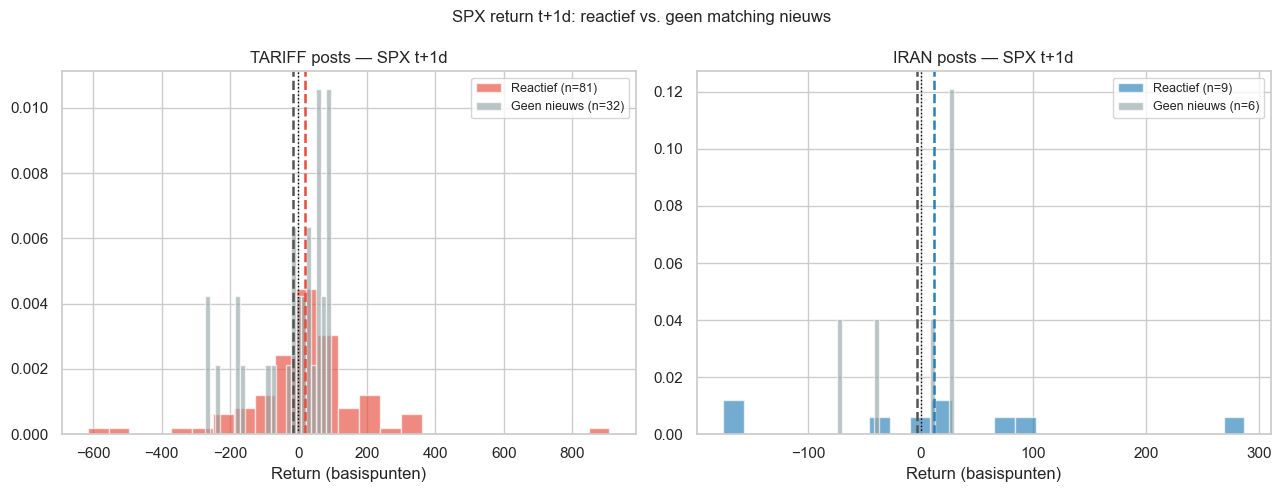

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, topic, color_r, color_n in [
    (axes[0], 'tariff', '#e74c3c', '#95a5a6'),
    (axes[1], 'iran',   '#2980b9', '#95a5a6'),
]:
    sub = gdelt[gdelt['topic'] == topic]
    react   = sub[sub['label'] == 'reactief']['SPX_ret_1d'].dropna()
    no_news = sub[sub['label'] == 'geen_nieuws']['SPX_ret_1d'].dropna()

    ax.hist(react,   bins=25, alpha=0.65, color=color_r,
            label=f'Reactief (n={len(react)})', density=True)
    ax.hist(no_news, bins=25, alpha=0.65, color=color_n,
            label=f'Geen nieuws (n={len(no_news)})', density=True)
    if not react.empty:
        ax.axvline(react.mean(),   color=color_r, linestyle='--', linewidth=1.8)
    if not no_news.empty:
        ax.axvline(no_news.mean(), color='#555', linestyle='--', linewidth=1.8)
    ax.axvline(0, color='black', linestyle=':', linewidth=1)
    ax.set_title(f'{topic.upper()} posts — SPX t+1d')
    ax.set_xlabel('Return (basispunten)')
    ax.legend(fontsize=9)

plt.suptitle('SPX return t+1d: reactief vs. geen matching nieuws', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES / '13_reactief_vs_geen_nieuws.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Lag vs. marktreactie: is er een verband?

Als de markt al gereageerd had op het nieuws, zou een langere lag gepaard moeten
gaan met een kleinere returns na de post (markt is al bijgewerkt).

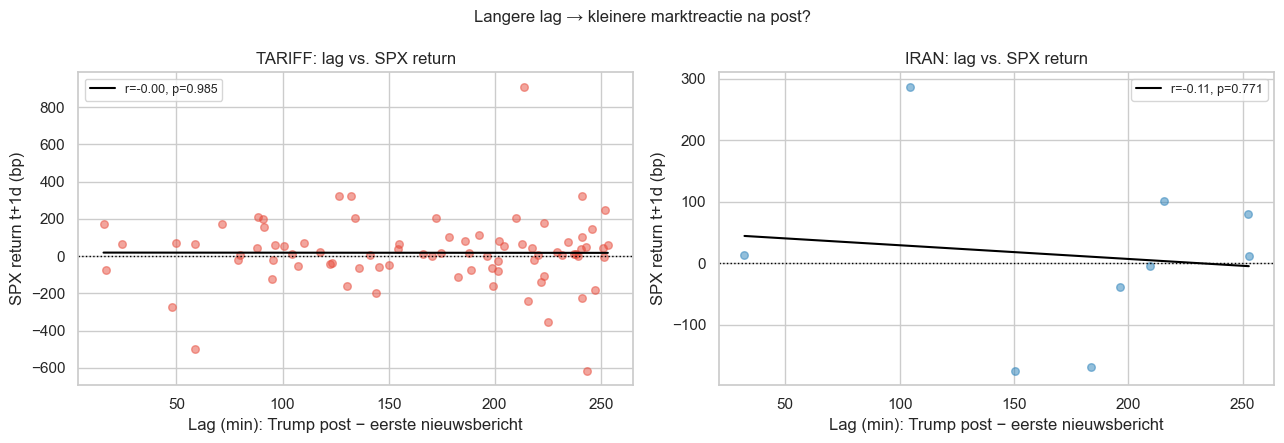

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, topic, color in [
    (axes[0], 'tariff', '#e74c3c'),
    (axes[1], 'iran',   '#2980b9'),
]:
    sub = gdelt[(gdelt['topic'] == topic) & gdelt['lag_minutes'].notna() & gdelt['SPX_ret_1d'].notna()]
    if len(sub) < 5:
        ax.set_title(f'{topic.upper()} — te weinig data')
        continue

    x = sub['lag_minutes']
    y = sub['SPX_ret_1d']
    ax.scatter(x, y, alpha=0.5, color=color, s=30)

    # Regressielijn
    m, b, r, p, _ = stats.linregress(x, y)
    xline = np.linspace(x.min(), x.max(), 100)
    ax.plot(xline, m*xline + b, color='black', linewidth=1.5,
            label=f'r={r:.2f}, p={p:.3f}')
    ax.axhline(0, color='black', linestyle=':', linewidth=1)
    ax.set_xlabel('Lag (min): Trump post − eerste nieuwsbericht')
    ax.set_ylabel('SPX return t+1d (bp)')
    ax.set_title(f'{topic.upper()}: lag vs. SPX return')
    ax.legend(fontsize=9)

plt.suptitle('Langere lag → kleinere marktreactie na post?', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES / '13_lag_vs_return.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. De 'geen_nieuws' posts: wat zijn dit?

Dit zijn de meest interessante posts — geen matching nieuwsbericht gevonden
in de 4 uur ervoor. Zijn dit posts over iets origineels, of false negatives
in de GDELT-filter?

In [8]:
geen_nieuws = gdelt[gdelt['label'] == 'geen_nieuws'].sort_values('post_time')
print(f'Totaal geen_nieuws posts: {len(geen_nieuws)}')
print()
for topic in ['tariff', 'iran']:
    sub = geen_nieuws[geen_nieuws['topic'] == topic]
    print(f'=== {topic.upper()} (n={len(sub)}) ===')
    for _, r in sub.head(8).iterrows():
        print(f'  [{r["post_time"].strftime("%Y-%m-%d %H:%M")}] SPX t+1d={r["SPX_ret_1d"]:.0f}bp')
        print(f'  {str(r["post_text"])[:200]}')
        print()

Totaal geen_nieuws posts: 38

=== TARIFF (n=32) ===
  [2025-02-09 10:55] SPX t+1d=67bp
  https://www.mediaite.com/tv/justin-trudeau-says-on-hot-mic-that-trump-is-serious-about-us-absorbing-canada-it-is-a-real-thing/

  [2025-02-15 17:47] SPX t+1d=24bp
  https://freebeacon.com/latest-news/trump-announces-reciprocal-tariffs-on-allies-competitors-to-address-unfair-trade-practices/

  [2025-02-16 19:13] SPX t+1d=24bp
  I am proud to nominate John Jovanovic to serve as the Chairman and Chief Executive Officer of the Export-Import Bank of the United States (EXIM). John will utilize his extensive experience in finance,

  [2025-02-17 03:59] SPX t+1d=24bp
  https://www.foxbusiness.com/politics/top-automaker-could-move-some-production-out-mexico-amid-trump-tariff-talks-ceo-says

  [2025-02-20 13:21] SPX t+1d=-172bp
  I’ll be calling our GREAT American Hockey Team this morning to spur them on towards victory tonight against Canada, which with FAR LOWER TAXES AND MUCH STRONGER SECURITY, will some

## 7. Nieuwstoon vs. marktreactie

GDELT geeft ook een toon-score van het nieuwsbericht (negatief = slecht nieuws).
Correleert de toon van het eerste nieuwsbericht met de marktreactie?

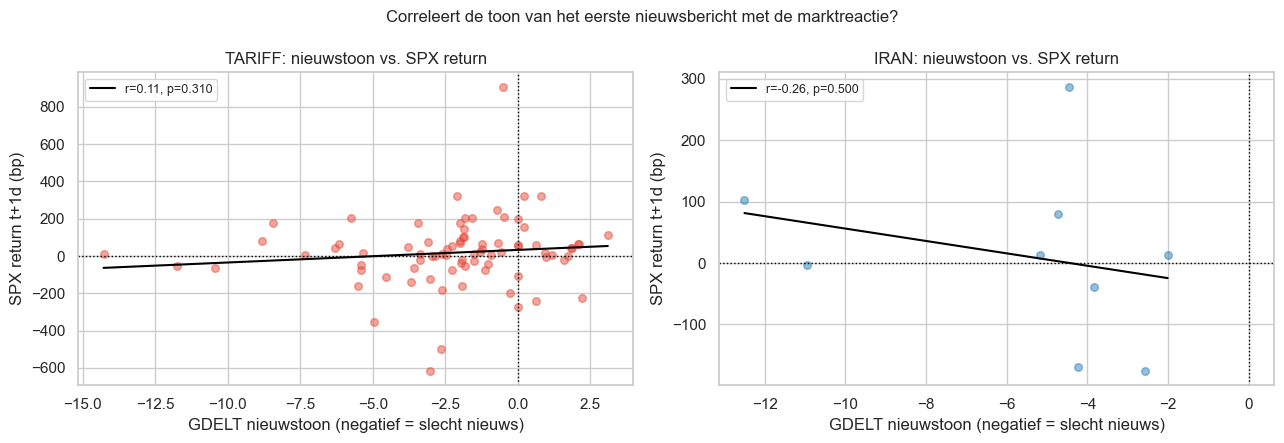

In [9]:
tone_df = gdelt[gdelt['news_tone'].notna() & gdelt['SPX_ret_1d'].notna()].copy()
tone_df['news_tone'] = pd.to_numeric(tone_df['news_tone'], errors='coerce')
tone_df = tone_df.dropna(subset=['news_tone'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, topic, color in [
    (axes[0], 'tariff', '#e74c3c'),
    (axes[1], 'iran',   '#2980b9'),
]:
    sub = tone_df[tone_df['topic'] == topic]
    if len(sub) < 5:
        ax.set_title(f'{topic.upper()} — te weinig data')
        continue
    x, y = sub['news_tone'], sub['SPX_ret_1d']
    ax.scatter(x, y, alpha=0.5, color=color, s=30)
    m, b, r, p, _ = stats.linregress(x, y)
    xline = np.linspace(x.min(), x.max(), 100)
    ax.plot(xline, m*xline + b, color='black', linewidth=1.5,
            label=f'r={r:.2f}, p={p:.3f}')
    ax.axhline(0, color='black', linestyle=':', linewidth=1)
    ax.axvline(0, color='black', linestyle=':', linewidth=1)
    ax.set_xlabel('GDELT nieuwstoon (negatief = slecht nieuws)')
    ax.set_ylabel('SPX return t+1d (bp)')
    ax.set_title(f'{topic.upper()}: nieuwstoon vs. SPX return')
    ax.legend(fontsize=9)

plt.suptitle('Correleert de toon van het eerste nieuwsbericht met de marktreactie?', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES / '13_nieuwstoon_vs_return.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Tijdlijn: lag over de tijd

Reageerde Trump sneller of langzamer op nieuws naarmate de tariff-cyclus vorderde?

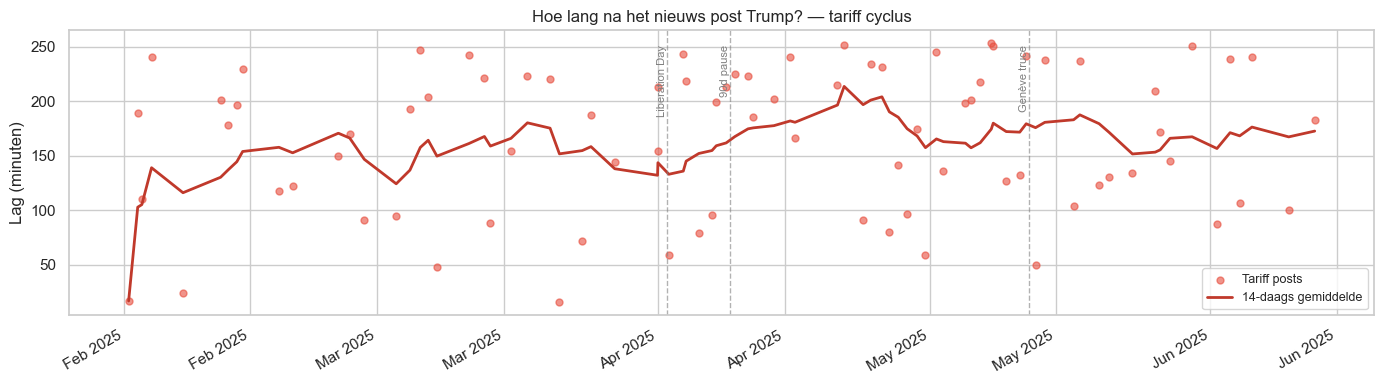

In [10]:
fig, ax = plt.subplots(figsize=(14, 4))

reactive_tariff = gdelt[(gdelt['topic']=='tariff') & (gdelt['label']=='reactief')].sort_values('post_time')

ax.scatter(reactive_tariff['post_time'], reactive_tariff['lag_minutes'],
           color='#e74c3c', alpha=0.6, s=25, label='Tariff posts')

# Voortschrijdend gemiddelde
if len(reactive_tariff) >= 7:
    rolling = reactive_tariff.set_index('post_time')['lag_minutes'].rolling('14D').mean()
    ax.plot(rolling.index, rolling.values, color='#c0392b', linewidth=2, label='14-daags gemiddelde')

# Anchor events
for d, label in [('2025-04-02','Liberation Day'), ('2025-04-09','90d pause'), ('2025-05-12','Genève truce')]:
    ax.axvline(pd.Timestamp(d, tz='UTC'), color='grey', linestyle='--', alpha=0.6, linewidth=1)
    ax.text(pd.Timestamp(d, tz='UTC'), ax.get_ylim()[1]*0.95 if ax.get_ylim()[1] > 0 else 250,
            label, rotation=90, va='top', ha='right', fontsize=8, color='grey')

ax.set_ylabel('Lag (minuten)')
ax.set_title('Hoe lang na het nieuws post Trump? — tariff cyclus')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig(FIGURES / '13_lag_over_tijd.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Samenvatting bevindingen

**Vul aan met je echte resultaten:**

1. **Reactief patroon**: In hoeveel % van de gevallen postte Trump NA het nieuws?
   Wat is de gemiddelde/mediane lag?

2. **Reactief vs. geen_nieuws — marktreactie**: Is de SPX-return significant
   groter voor posts zonder matchend nieuwsbericht? Als ja, steunt dit de
   informatieve hypothese. Als nee, ook 'geen_nieuws' posts hebben geen extra
   marktimpact.

3. **Lag vs. return**: Is er een negatief verband? (langere lag = markt al
   bijgewerkt = kleinere return na post). Dat zou consistent zijn met de
   common-cause interpretatie.

4. **Nieuwstoon**: Correleert de toon van het eerste nieuwsbericht met de
   marktreactie? Als ja, is het nieuws zelf (niet Trump's post) de verklarende
   variabele.

5. **Geen_nieuws posts inhoudelijk**: Zijn dit posts over iets origineels
   of false negatives in de GDELT-filter?

**Voor je scriptie:**

> *"Om het common-cause probleem te adresseren hebben we via het GDELT-project
> voor elke post het tijdstip van het eerste matching nieuwsbericht bepaald.
> In [X]% van de gevallen (n=[Y]) postte Trump aantoonbaar na het nieuws,
> met een gemiddelde lag van [Z] minuten. Dit patroon is consistent over beide
> thema's (tarieven: mediaan [X]m, Iran: mediaan [X]m) en ondersteunt de
> common-cause interpretatie: Trump reageert op dezelfde onderliggende events
> als de markt, maar met vertraging."*